In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:

df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

src = "/content/drive/MyDrive/Zepto_Capstone_Module1/titanic.csv"
shutil.copy(src, "/content/titanic.csv")

df = pd.read_csv("/content/titanic.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Zepto_Capstone_Module1/titanic.csv'

In [5]:
!wget -q https://raw.githubusercontent.com/ssdoravijju-arch/Zepto_Capstone_Project/main/titanic.csv -O titanic.csv

df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining class balance:")
print(y_train.value_counts())

Train shape: (712, 14)
Test shape: (179, 14)

Training class balance:
survived
0    439
1    273
Name: count, dtype: int64


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804,0.793,0.667,0.724,0.844
1,Decision Tree,0.816,0.790,0.710,0.748,0.790
2,Random Forest,0.816,0.800,0.696,0.744,0.829


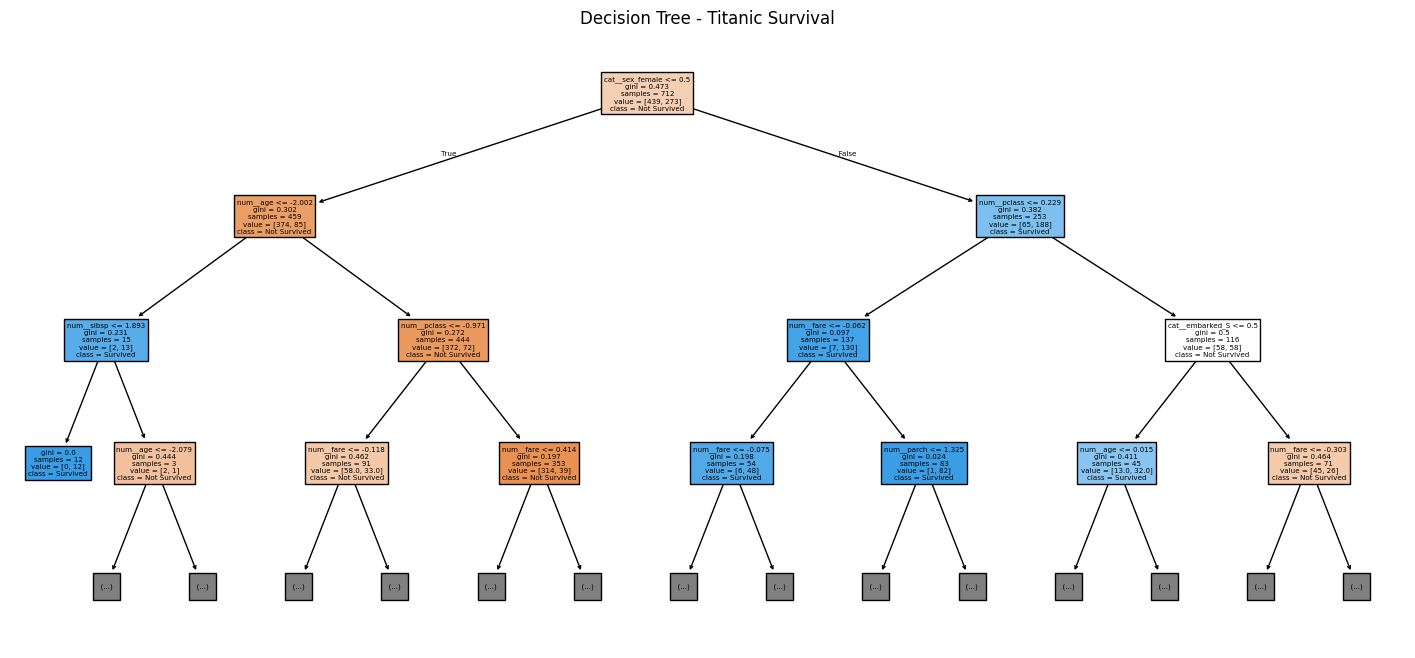

In [8]:
dt_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

feature_names = dt_pipeline.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(18, 8))
plot_tree(
    dt_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)
plt.title("Decision Tree - Titanic Survival")
plt.show()

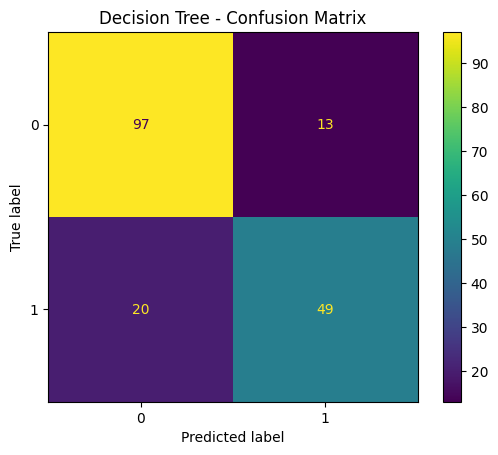

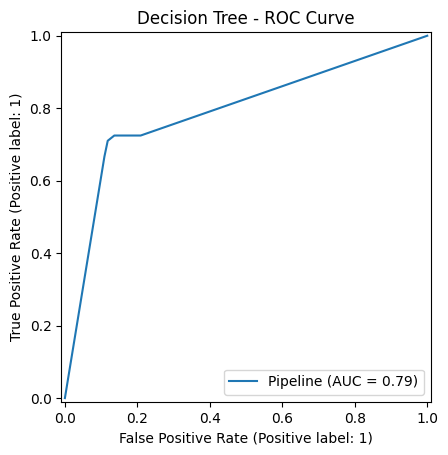

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

pred_dt = dt_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, pred_dt)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(dt_pipeline, X_test, y_test)
plt.title("Decision Tree - ROC Curve")
plt.show()

In [10]:
from imblearn.over_sampling import SMOTE

# Preprocess training/test data
Xtr = preprocessor.fit_transform(X_train)
Xte = preprocessor.transform(X_test)

rows = []

for name, model in [
    ("Baseline", RandomForestClassifier(random_state=42)),
    ("Balanced", RandomForestClassifier(class_weight="balanced", random_state=42))
]:
    model.fit(Xtr, y_train)
    p = model.predict(Xte)
    rows.append([name, precision_score(y_test,p), recall_score(y_test,p), f1_score(y_test,p)])

# SMOTE only on training data
Xs, ys = SMOTE(random_state=42).fit_resample(Xtr, y_train)
m = RandomForestClassifier(random_state=42).fit(Xs, ys)
p = m.predict(Xte)
rows.append(["SMOTE", precision_score(y_test,p), recall_score(y_test,p), f1_score(y_test,p)])

display(pd.DataFrame(rows, columns=["Method","Precision","Recall","F1"]).round(3))

,Method,Precision,Recall,F1
0,Baseline,0.800,0.696,0.744
1,Balanced,0.800,0.696,0.744
2,SMOTE,0.746,0.725,0.735


In [11]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__max_features": ["sqrt", "log2"]
}

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        oob_score=True,
        random_state=42
    ))
])

grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_.named_steps["model"]

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))
print("OOB Score:", round(best_rf.oob_score_, 3))

Best Parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV F1: 0.748
OOB Score: 0.819


MAE: 25.182
RMSE: 58.52
R2: 0.177
Adjusted R2: 0.154


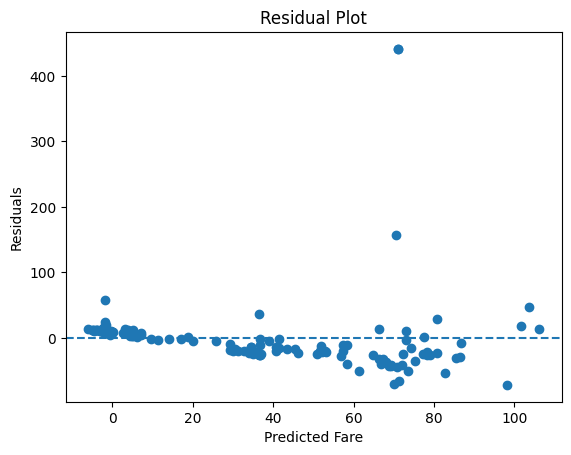

In [12]:


reg_df = df[["age","pclass","sibsp","parch","fare"]].dropna()

Xr = reg_df.drop(columns="fare")
yr = reg_df["fare"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)

pred = reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, pred)
rmse = mean_squared_error(yr_test, pred) ** 0.5
r2 = r2_score(yr_test, pred)

n = len(yr_test)
p = Xr_test.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("MAE:", round(mae,3))
print("RMSE:", round(rmse,3))
print("R2:", round(r2,3))
print("Adjusted R2:", round(adj_r2,3))

residuals = yr_test - pred
plt.scatter(pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [13]:
# Save and reload best complete pipeline
best_pipeline = grid.best_estimator_

joblib.dump(best_pipeline, "titanic_best_pipeline.joblib")

loaded_pipeline = joblib.load("titanic_best_pipeline.joblib")

sample = X_test.head(3)
print("Reloaded predictions:", loaded_pipeline.predict(sample))
print("Pipeline saved and reloaded successfully.")

Reloaded predictions: [0 0 0]
Pipeline saved and reloaded successfully.


In [16]:
from google.colab import files
files.download("titanic_best_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>